In [2]:
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.distributions import Categorical

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

import importlib

In [24]:
from data_handling import read_data, process_timestamp, get_min_since, transforms
import network_builds
import supp_funcs
import data_builder
import environments
import model_trainers
import plotter

In [7]:
plt.rcParams['figure.figsize'] = [20, 10]

In [15]:
###data for a single actor###

In [16]:
data = read_data('FB')
min_since = get_min_since(data)
data_df = process_timestamp(data, min_since)

In [17]:
t = transforms(data_df)
t.all_transforms()
t.suplemental_factors()

In [18]:
data_df = t.transformed

In [19]:
test_shape = int(0.05*data_df.shape[0])
train_shape = data_df.shape[0] - test_shape

In [20]:
train, test = data_df[:train_shape], data_df[train_shape:]

In [21]:
###data for  multiple actors###

In [25]:
bd = data_builder.build_datas()

In [ ]:
### if need be to reload a module after updates
importlib.reload(model_trainers)
importlib.reload(environments)

In [27]:
###train with single actor###

In [29]:
envs = environments.environment(train, t.scaler.mean_, t.scaler.var_, action_dim=2, discrete=False)

In [33]:
trainer = model_trainers.trainer_tester(envs, discrete=False)

In [34]:
trainer.train(1)

In [36]:
envs_test = environments.environment(test, t.scaler.mean_, t.scaler.var_, action_dim=2, discrete=False)

In [37]:
trainer.test(envs_test)

In [38]:
###plots for single actor

In [40]:
p = plotter.plotter(trainer, envs, envs_test)

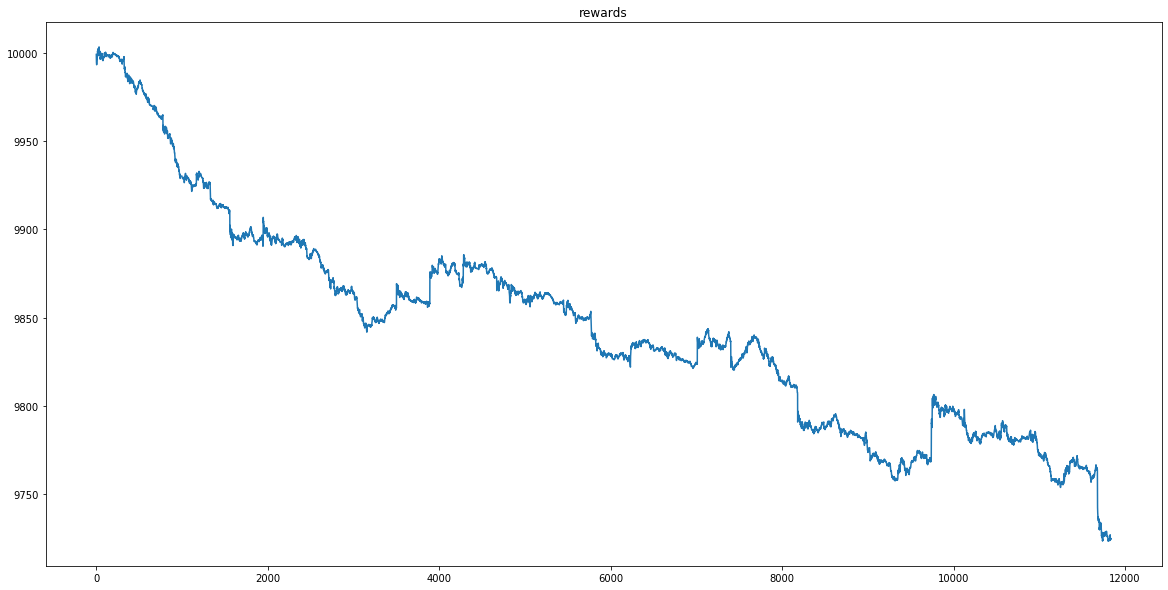

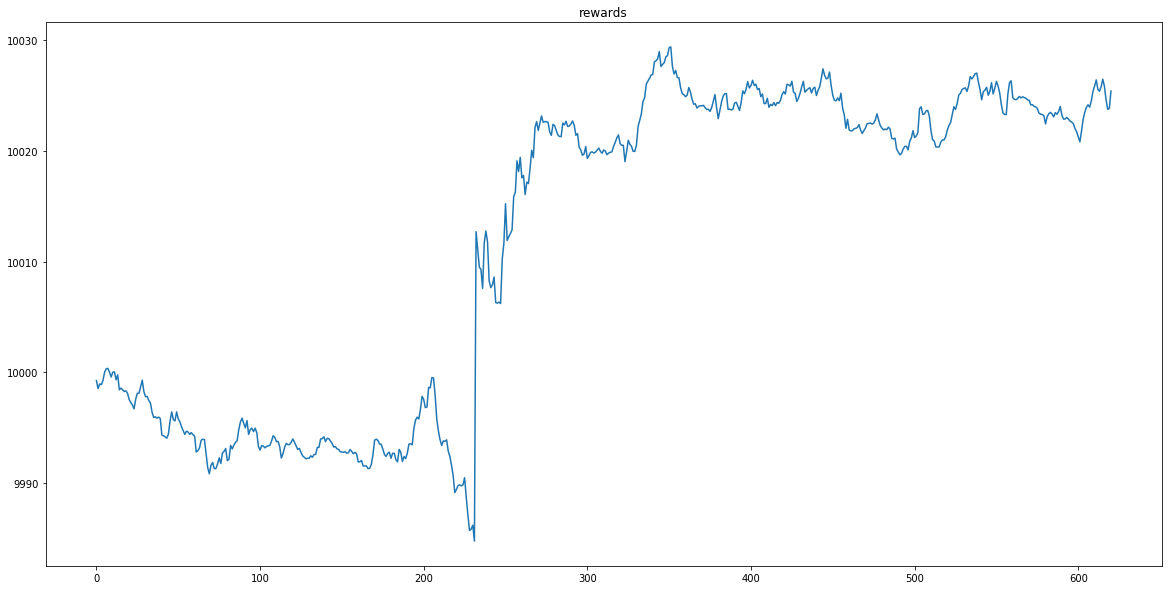

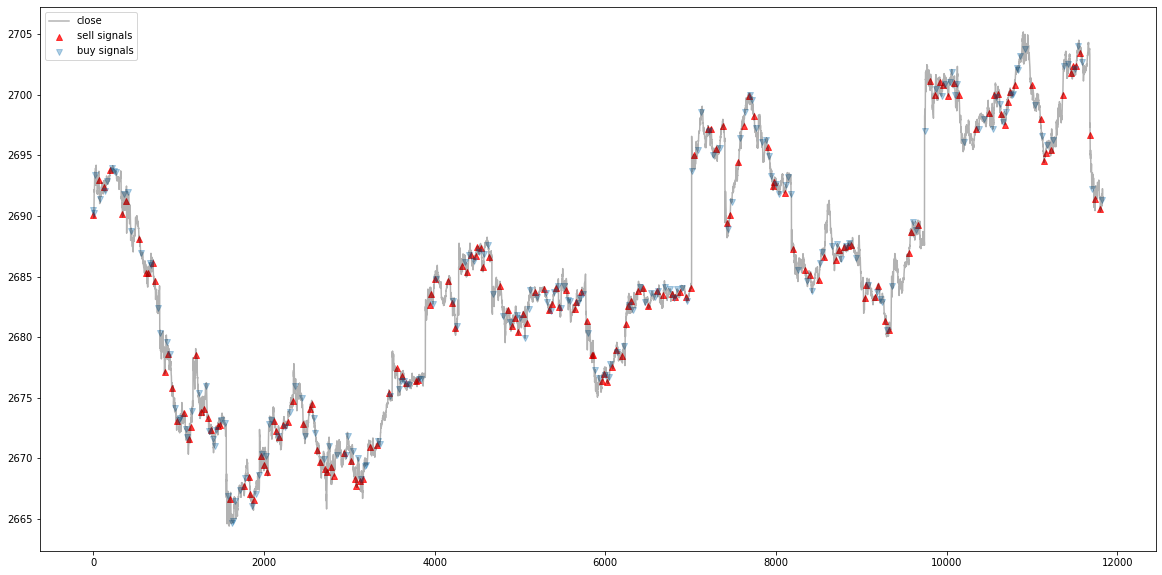

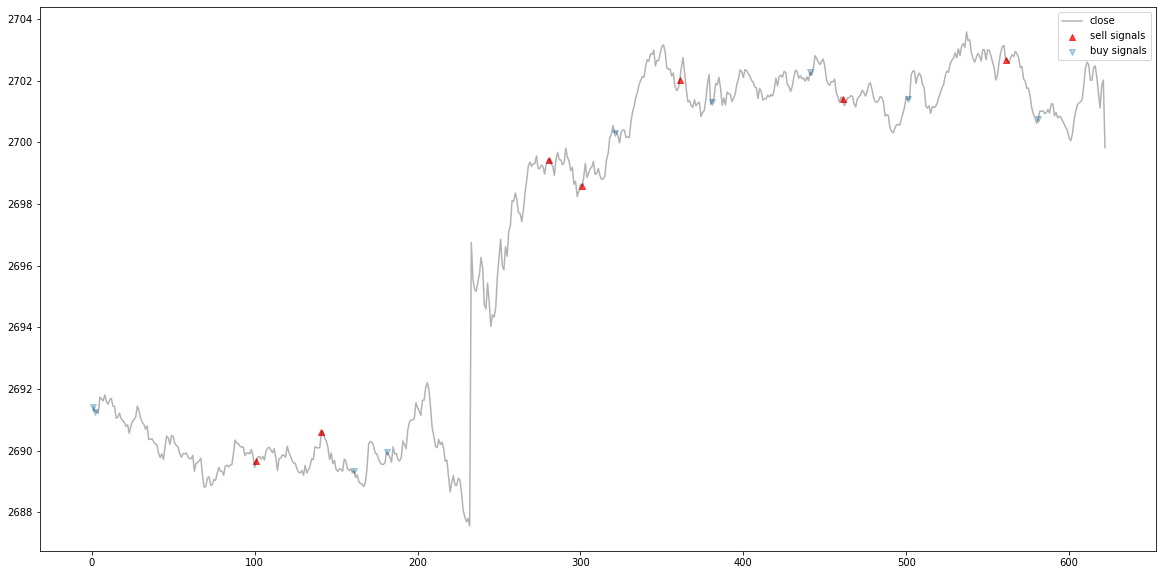

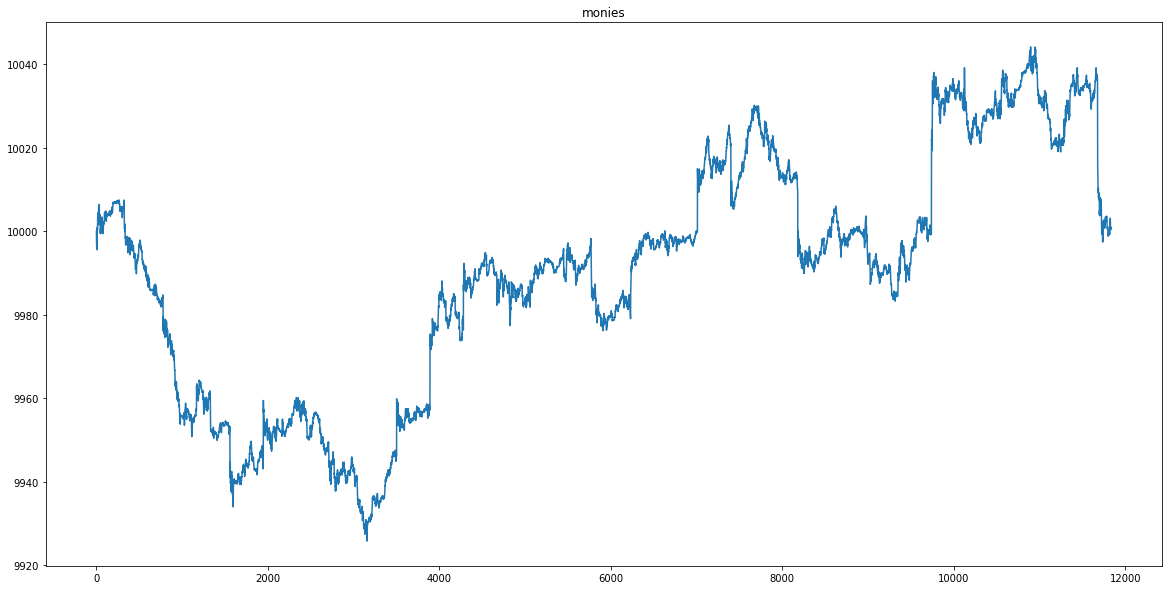

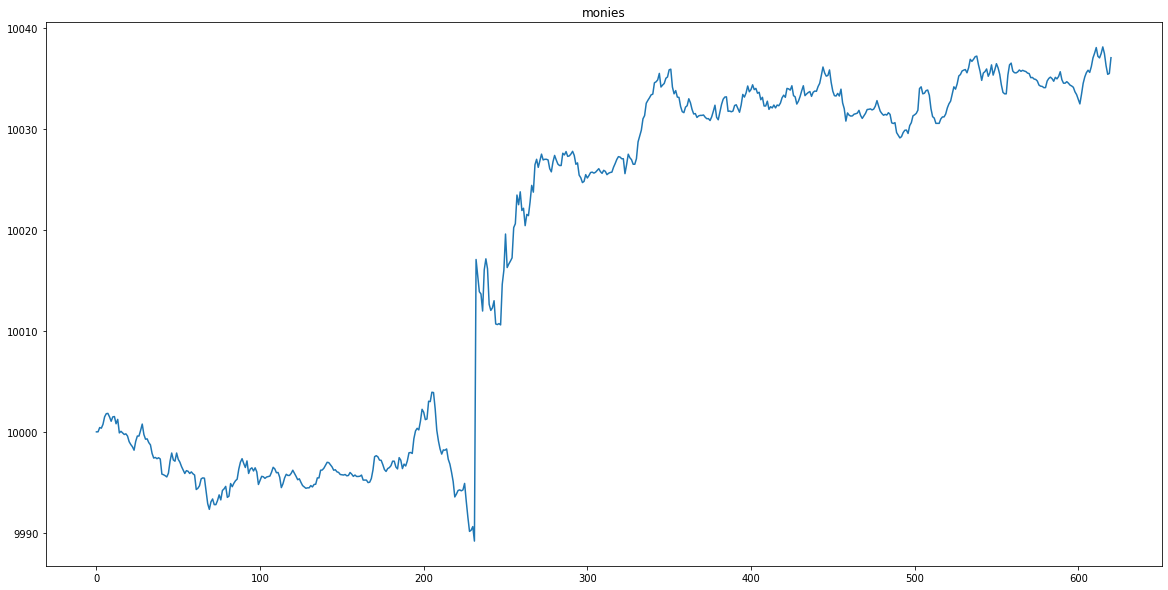

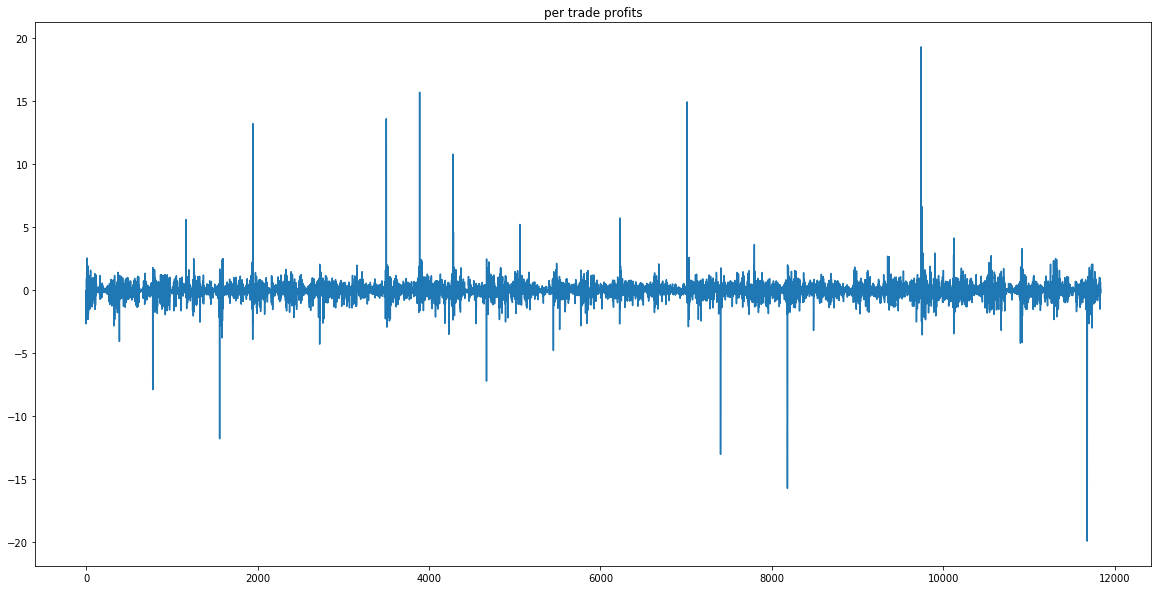

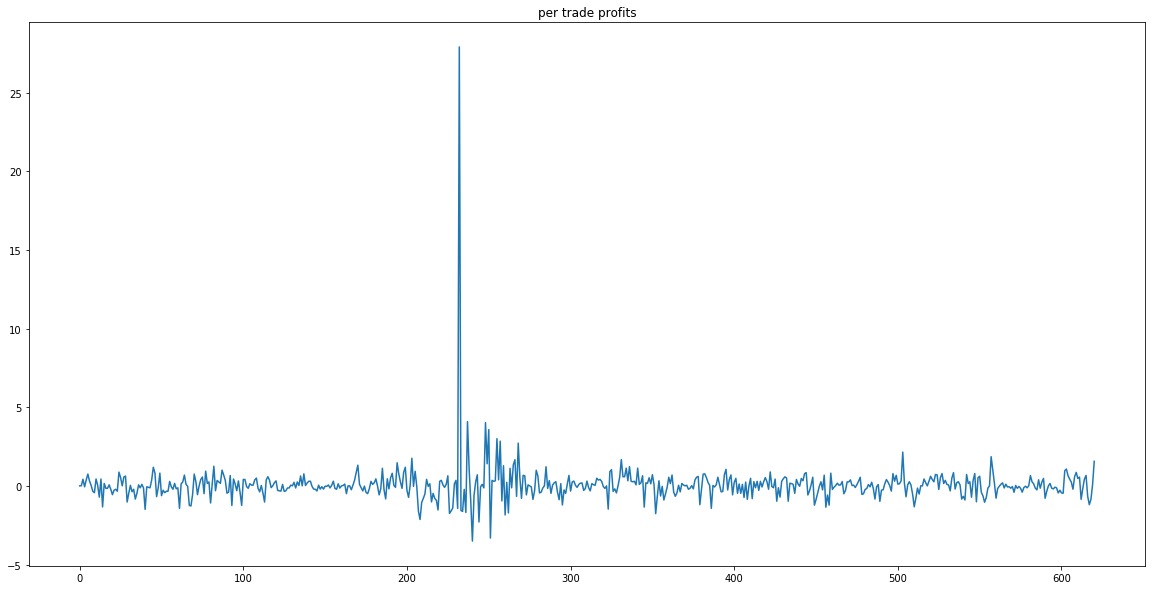

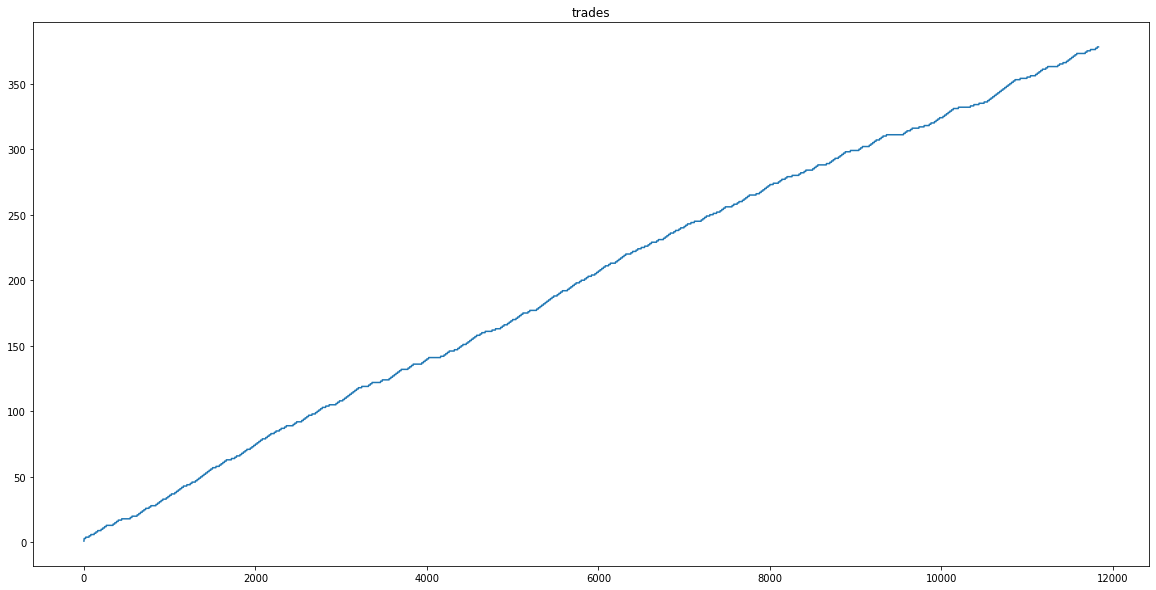

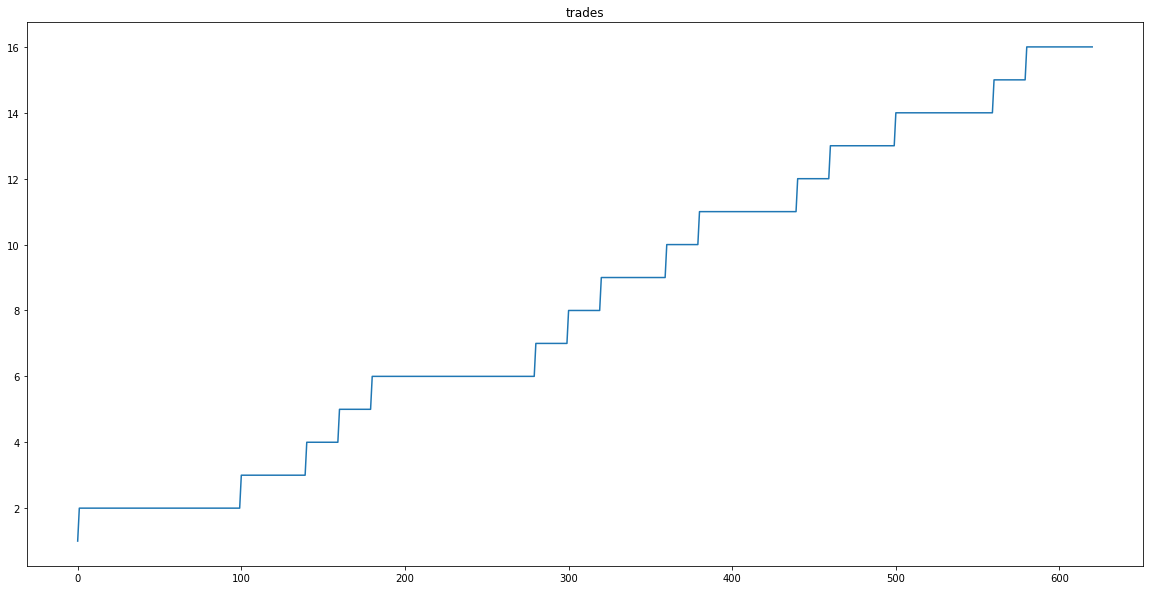

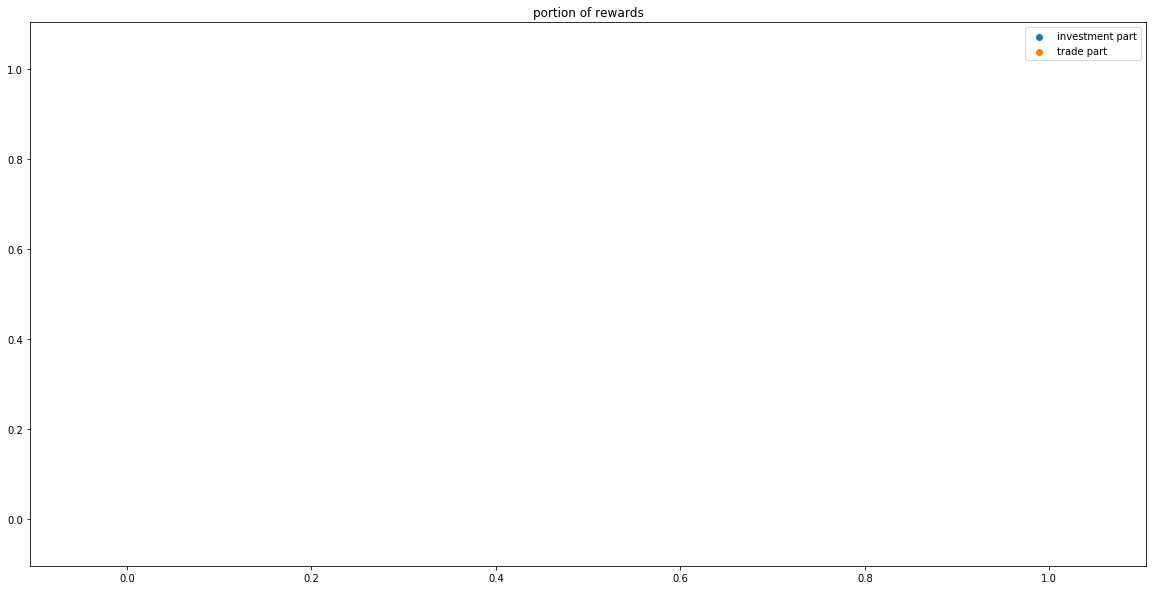

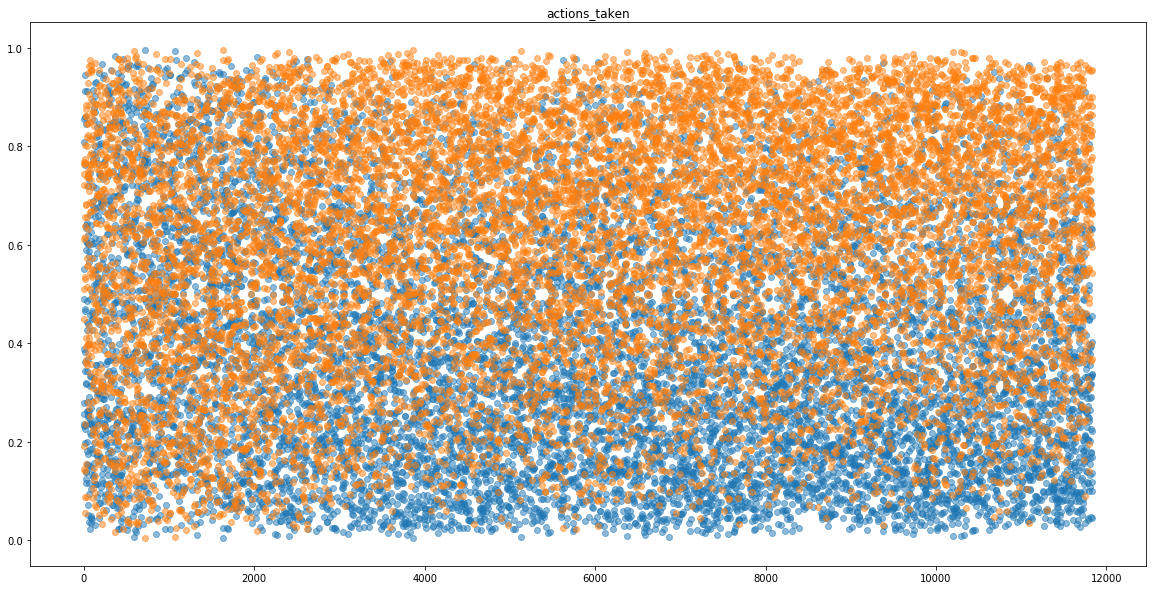

In [53]:
p.plot_rewards()
p.plot_rewards(test = True)
p.plot_signals()
p.plot_signals(test = True)
p.plot_monies()
p.plot_monies(test = True)
p.plot_profits()
p.plot_profits(test = True)
p.plot_trades()
p.plot_trades(test = True)
p.plot_comparison()
p.plot_actions()

In [54]:
###train with multiple actors###

In [56]:
multi_t = model_trainers.trainer_tester_multiple(bd, discrete = False)

In [58]:
#envs_baseline = environment(data_df, t.scaler.mean_, t.scaler.var_, action_dim=2, discrete=False)
#multi_t.baseline(envs_baseline)

In [ ]:
multi_t.train()

In [59]:
###plots for multiple actors###

In [61]:
p = plotter.plotter(multi_t, multi_t.envs, None)

In [ ]:
p.plot_rewards()
p.plot_signals()
p.plot_monies()
p.plot_profits()
p.plot_trades()
p.plot_comparison()
p.plot_actions()